In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Veriyi yüklüyoruz.
df = pd.read_csv('/content/drive/MyDrive/AI_Human.csv')
print(df.columns)

Index(['text', 'generated'], dtype='object')


--- Sınıf Dağılımı ---
generated
0.0    305797
1.0    181438
Name: count, dtype: int64
--------------------


/tmp/ipykernel_1887/2774332847.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='generated', data=df, palette='viridis')


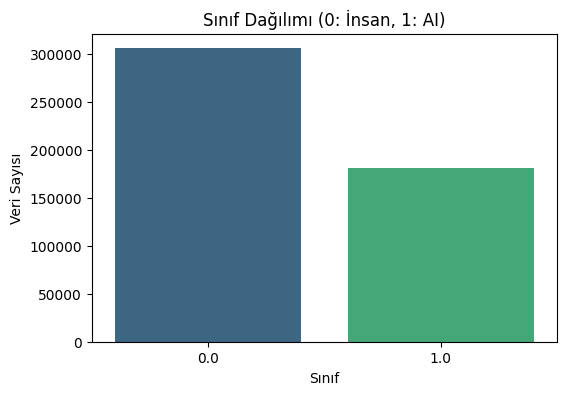

--- Genel Metin Uzunluğu İstatistikleri ---
count    487235.000000
mean        393.096214
std         168.593328
min           0.000000
25%         278.000000
50%         363.000000
75%         471.000000
max        1668.000000
Name: word_count, dtype: float64
--------------------
--- Sınıf Bazında Ortalama Kelime Sayısı ---
generated
0.0    421.98518
1.0    344.40653
Name: word_count, dtype: float64


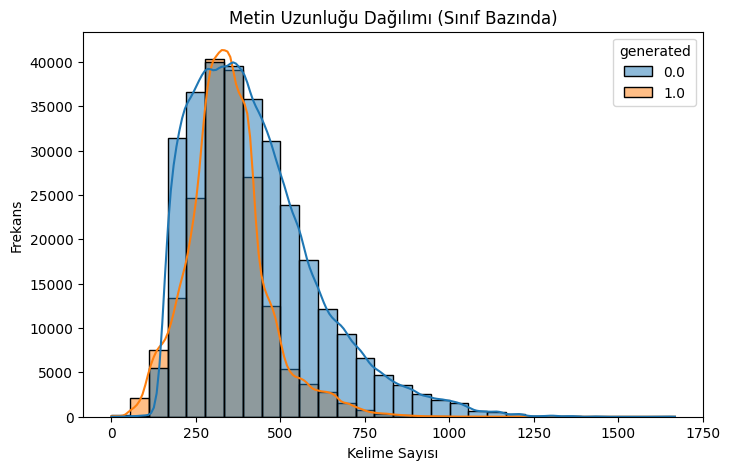


--- ÖRNEK METİN ANALİZİ  ---
[İNSAN] | In my opinion I think that we shouldn't continue with elector college. I think we should change it to election by popular vote for president of the un...
--------------------------------------------------
[İNSAN] | Many of us are used to getting somewhere by simply using a car, but should we always use a car. If we limit car usage we can solve most of our problem...
--------------------------------------------------
[İNSAN] | Student would be a benefit if they are to be able to take online you need to proud by your self because not going late in TGE class be on TGE time and...
--------------------------------------------------
[AI] | Deal Senator, I am writing to you today to express my support for abolishing the Electoral College and electing the president of the United States by ...
--------------------------------------------------
[AI] | Sure, here's my essay response: Successful people are those who have achieved their goals and made a signi

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Veriyi yüklüyoruz.
df = pd.read_csv('/content/drive/MyDrive/AI_Human.csv')

# --- 3.1.1 SINIF DAĞILIMI (Class Distribution) ---
print("--- Sınıf Dağılımı ---")
print(df['generated'].value_counts())
print("-" * 20)

plt.figure(figsize=(6, 4))
#Viridis göz yormayan bir renk paletidir, bu sebeple tercih edilmiştir.
sns.countplot(x='generated', data=df, palette='viridis')
plt.title('Sınıf Dağılımı (0: İnsan, 1: AI)')
plt.xlabel('Sınıf')
plt.ylabel('Veri Sayısı')
plt.show()

# --- 3.1.2 METİN UZUNLUĞU İSTATİSTİKLERİ ---
# Kelime sayısını hesaplıyoruz.
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

print("--- Genel Metin Uzunluğu İstatistikleri ---")
#describe() metodu ile ortalama, medyan gibi bir çok istatistiksel veriye ulaşabiliyoruz.
print(df['word_count'].describe())
print("-" * 20)

# Sınıf bazında ortalama kelime sayısını hesaplayarak her sınıfın genel metin uzunluğu bilgisini elde ediyoruz.
# Bu bilgi bize insan ve ai tarafından üretilen metinlerin ortalama uzunluğunu söylüyor.
print("--- Sınıf Bazında Ortalama Kelime Sayısı ---")
print(df.groupby('generated')['word_count'].mean())

# Uzunluk Dağılımı Grafiği (Histogram)
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='word_count', hue='generated', kde=True, bins=30)
plt.title('Metin Uzunluğu Dağılımı (Sınıf Bazında)')
plt.xlabel('Kelime Sayısı')
plt.ylabel('Frekans')
plt.show()

# --- 3.1.3 ÖRNEK METİNLER (İLK 100 KARAKTER) ---
print("\n" + "="*50)
print("--- ÖRNEK METİN ANALİZİ  ---")
print("="*50)

# Gruplayarak her kısım için (insan ve ai) örnekleri seçiyoruz.
examples = df.groupby('generated').apply(lambda x: x.sample(min(len(x), 3)), include_groups=False).reset_index()

for index, row in examples.iterrows():
    # 1. Satır sonlarını (\n) ve fazla boşlukları temizleyip tek satıra indiriyoruz.Böylece daha düzgün bir görünüme ulaşıyoruz.
    # Metni tüm gereksiz olan boşluklardan arındırıyoruz.
    clean_text = " ".join(row['text'].split())

    # 2. Sınıf isimlerinde 0 ve 1 yerine İnsan ve Ai kullanarak daha anlaşılır olmasını sağlıyoruz.
    label_name = "İNSAN" if row['generated'] == 0 else "AI"

    # 3. Bir kutu/çizgi içinde anlaşılır ve düzgün vir şekilde gösteriyoruz.
    print(f"[{label_name}] | {clean_text[:150]}...")
    print("-" * 50)